# Análisis de Sensibilidad Emocional en LLMs
En este notebook analizaremos los resultados obtenidos de los experimentos con los modelos Llama 3, Mistral y Phi-3. El objetivo es determinar cómo varía la longitud, diversidad léxica, y otras métricas lingüísticas según la emoción del prompt.


In [1]:
import pandas as pd
import numpy as np
import os
import glob
from textblob import TextBlob
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jonat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jonat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Cargar y Unificar Datasets
Dado que los experimentos guardaron archivos CSV separados por modelo, vamos a leerlos todos desde la carpeta `dataset_experimento/` y combinarlos en un único DataFrame, añadiendo una columna para identificar el modelo.


In [2]:
# Cargar todos los CSVs
ruta_datasets = "dataset_experimento/*.csv"
archivos = glob.glob(ruta_datasets)

dataframes = []
for archivo in archivos:
    # Extraer el nombre del modelo del archivo (ej. llama3_experimento.csv -> llama3)
    nombre_modelo = os.path.basename(archivo).replace("_experimento.csv", "")
    df_temp = pd.read_csv(archivo)
    df_temp["model"] = nombre_modelo
    dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)

# Renombrar columnas para consistencia con el análisis
df.rename(columns={
    "emocion": "emotion", 
    "respuesta": "response", 
    "longitud": "length"
}, inplace=True)

df.head()


,emotion,iteracion,prompt,response,length,diversidad,model
0,neutral,0,Explícame cómo funciona una red neuronal.,¡Claro! Una red neuronal (también conocida com...,122,0.762295,llama3
1,neutral,1,Explícame cómo funciona una red neuronal.,¡Claro! Una red neuronal (también conocida com...,118,0.686441,llama3
2,neutral,2,Explícame cómo funciona una red neuronal.,Las redes neuronales! Son uno de los avances m...,126,0.825397,llama3
3,neutral,3,Explícame cómo funciona una red neuronal.,Las redes neuronales (RN) son modelos matemáti...,126,0.722222,llama3
4,neutral,4,Explícame cómo funciona una red neuronal.,Las redes neuronales (RN) son un tipo de model...,120,0.741667,llama3


## 2. Feature Engineering y Funciones Avanzadas
Aquí calculamos características adicionales del texto como la diversidad léxica, la longitud media de las oraciones, la polaridad del sentimiento y la subjetividad.


In [ ]:
def lexical_diversity(text):
    words = str(text).split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

def sentence_length(text):
    sentences = nltk.sent_tokenize(str(text))
    if len(sentences) == 0:
        return 0
    return np.mean([len(s.split()) for s in sentences])

def get_sentiment(text):
    # Sentiment polaridad (-1 a 1)
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    # Subjetividad (0 a 1)
    return TextBlob(str(text)).sentiment.subjectivity

def pronoun_usage(text):
    pronouns = ["yo", "tú", "te", "usted", "nosotros", "mí", "conmigo"]
    words = str(text).lower().split()
    return sum(1 for w in words if w in pronouns)

# Aplicar funciones al dataset
df["lexical_diversity"] = df["response"].apply(lexical_diversity)
df["sentence_length"] = df["response"].apply(sentence_length)
df["sentiment"] = df["response"].apply(get_sentiment)
df["subjectivity"] = df["response"].apply(get_subjectivity)
df["pronouns"] = df["response"].apply(pronoun_usage)

df.head()


,emotion,iteracion,prompt,response,length,diversidad,model,lexical_diversity,sentence_length,sentiment,subjectivity,pronouns
0,neutral,0,Explícame cómo funciona una red neuronal.,¡Claro! Una red neuronal (también conocida com...,122,0.762295,llama3,0.762295,12.200000,-0.12,0.2,0
1,neutral,1,Explícame cómo funciona una red neuronal.,¡Claro! Una red neuronal (también conocida com...,118,0.686441,llama3,0.686441,13.111111,0.00,0.0,0
2,neutral,2,Explícame cómo funciona una red neuronal.,Las redes neuronales! Son uno de los avances m...,126,0.825397,llama3,0.825397,12.600000,-0.23,0.5,1
3,neutral,3,Explícame cómo funciona una red neuronal.,Las redes neuronales (RN) son modelos matemáti...,126,0.722222,llama3,0.722222,12.600000,0.00,0.0,0
4,neutral,4,Explícame cómo funciona una red neuronal.,Las redes neuronales (RN) son un tipo de model...,120,0.741667,llama3,0.741667,17.142857,0.00,0.0,1


## 3. Resumen General
Agrupamos los datos por modelo y por emoción para observar la media y la desviación estándar de nuestras métricas clave.


In [4]:
summary = df.groupby(["model", "emotion"]).agg({
    "length": ["mean", "std"],
    "sentiment": ["mean", "std"],
    "lexical_diversity": "mean",
    "sentence_length": "mean",
    "subjectivity": "mean",
    "pronouns": "mean"
}).reset_index()

summary


model      emotion length           sentiment            \
                           mean       std      mean       std   
0    llama3     ansiedad  116.6  2.880972 -0.064000  0.092087   
1    llama3     cortesia  123.0  1.870829  0.046667  0.104350   
2    llama3        enojo  125.6  4.037326 -0.138333  0.120991   
3    llama3  frustracion  119.8  4.494441 -0.020625  0.046119   
4    llama3      neutral  122.4  3.577709 -0.070000  0.103441   
5    llama3     urgencia  118.0  4.358899 -0.064667  0.060901   
6   mistral     ansiedad  107.2  2.774887 -0.144000  0.112606   
7   mistral     cortesia  109.4  3.646917 -0.172000  0.047645   
8   mistral        enojo  106.2  4.438468 -0.099619  0.087455   
9   mistral  frustracion  105.8  1.643168 -0.098317  0.122013   
10  mistral      neutral  110.0  3.937004 -0.175952  0.063102   
11  mistral     urgencia  112.2  4.086563 -0.161190  0.073055   
12     phi3     ansiedad  111.4  4.393177 -0.138333  0.261114   
13     phi3     cortesia  107.0  4.000000 -0.023333  0.158815   
14     phi3        enojo  113.2  4.711688 -0.040000  0.065192   
15     phi3  frustracion  109.2  7.758866 -0.123333  0.158815   
16     phi3      neutral  114.4  0.894427 -0.024000  0.053666   
17     phi3     urgencia  111.0  4.582576 -0.014000  0.063087   
18  qwen14b     ansiedad  126.6  3.577709 -0.091500  0.122035   
19  qwen14b     cortesia  130.0  7.516648 -0.115000  0.079582   
20  qwen14b        enojo  131.0  3.674235 -0.181667  0.089443   
21  qwen14b  frustracion  130.2  3.114482 -0.248000  0.106160   
22  qwen14b      neutral  124.2  4.381780 -0.262095  0.076426   
23  qwen14b     urgencia  129.2  6.610598 -0.223333  0.128774   

   lexical_diversity sentence_length subjectivity pronouns  
                mean            mean         mean     mean  
0           0.792261       11.156061     0.288095      1.2  
1           0.770743       12.081169     0.110000      1.0  
2           0.772105       12.880000     0.241190      1.2  
3           0.796705       12.410101     0.082500      0.8  
4           0.747604       13.530794     0.140000      0.4  
5           0.749701       11.252626     0.193333      0.8  
6           0.733298       17.197381     0.262667      0.2  
7           0.712157       13.879048     0.286667      0.0  
8           0.769193       14.134444     0.240000      0.0  
9           0.750612       16.080476     0.220794      0.6  
10          0.727440       16.720952     0.338095      0.0  
11          0.697215       21.733333     0.326871      0.2  
12          0.800632       21.580000     0.250000      0.4  
13          0.818966       19.220952     0.221667      0.2  
14          0.784935       22.923810     0.176667      0.2  
15          0.819539       20.465714     0.266667      0.4  
16          0.783243       21.977143     0.090000      0.2  
17          0.772083       21.345714     0.121000      0.0  
18          0.766428       13.497778     0.263929      0.6  
19          0.776243       13.857778     0.274603      1.0  
20          0.750823       14.017222     0.434762      0.4  
21          0.783458       14.398283     0.427619      0.6  
22          0.770612       15.645635     0.469333      0.4  
23          0.765427       14.273081     0.458061      0.6

## 4. Variabilidad por Modelo
Calculamos la desviación estándar de la longitud de las respuestas para cada modelo, lo que nos da una idea de qué modelo es más inestable o variable en sus respuestas.


In [5]:
variability = df.groupby("model")["length"].std()
variability


model
llama3     4.566369
mistral    3.971739
phi3       5.041095
qwen14b    5.224170
Name: length, dtype: float64

## 5. Análisis de Varianza (ANOVA)
Realizamos un test ANOVA para determinar si el efecto de la emoción sobre la longitud de la respuesta es estadísticamente significativo para cada modelo. Además, calculamos el tamaño del efecto (Eta cuadrado).


In [6]:
def anova_effect(df, variable, model_name):
    subset = df[df["model"] == model_name]
    
    groups = [subset[subset["emotion"] == e][variable] for e in subset["emotion"].unique()]
    
    if len(groups) < 2:
        return np.nan, np.nan, np.nan
        
    f_stat, p_val = f_oneway(*groups)
    
    # Eta squared (tamaño de efecto)
    grand_mean = subset[variable].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((subset[variable] - grand_mean)**2)
    
    eta_sq = ss_between / ss_total if ss_total != 0 else 0
    
    return f_stat, p_val, eta_sq

for model in df["model"].unique():
    f, p, eta = anova_effect(df, "length", model)
    print(f"Modelo: {model} -> F={f:.3f}, p={p:.5f}, eta²={eta:.3f}")


Modelo: llama3 -> F=4.259, p=0.00650, eta²=0.470
Modelo: mistral -> F=2.461, p=0.06177, eta²=0.339
Modelo: phi3 -> F=1.539, p=0.21516, eta²=0.243
Modelo: qwen14b -> F=1.312, p=0.29237, eta²=0.215


## 6. Correlaciones
Veamos si existe alguna correlación entre la longitud, el sentimiento, la diversidad léxica y la subjetividad.


In [7]:
corr = df[["length", "sentiment", "lexical_diversity", "subjectivity"]].corr()
corr


,length,sentiment,lexical_diversity,subjectivity
length,1.000000,-0.122165,-0.066497,0.185814
sentiment,-0.122165,1.000000,-0.066820,-0.822434
lexical_diversity,-0.066497,-0.066820,1.000000,0.085726
subjectivity,0.185814,-0.822434,0.085726,1.000000


## 7. Visualizaciones
Finalmente, generamos gráficos para entender mejor las distribuciones y las relaciones entre nuestras variables.


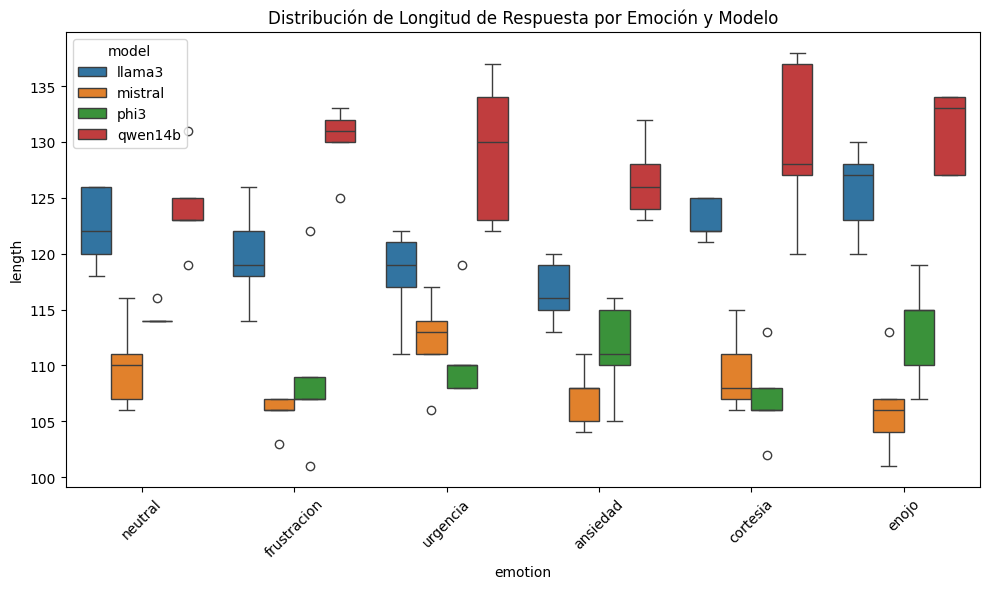

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="emotion", y="length", hue="model")
plt.title("Distribución de Longitud de Respuesta por Emoción y Modelo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


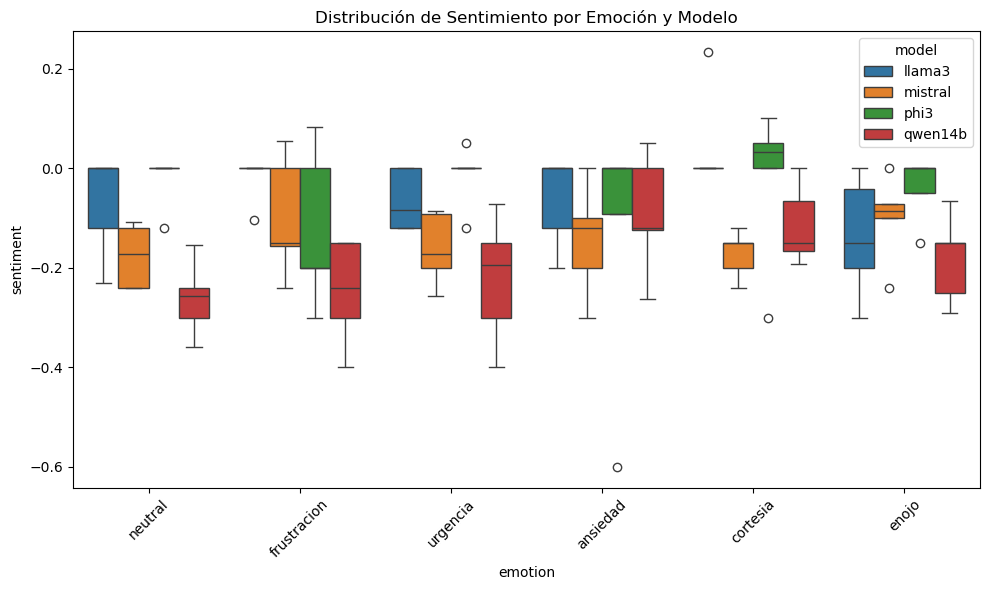

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="emotion", y="sentiment", hue="model")
plt.title("Distribución de Sentimiento por Emoción y Modelo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


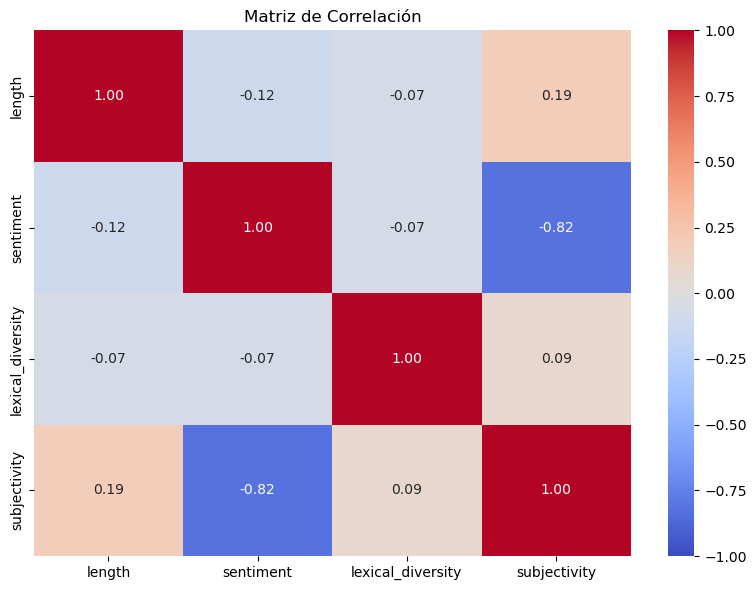

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()
